## Necessary code import



In [1]:
from pathlib import Path

search_folder = Path("dog_search_abs")

import pandas as pd
import numpy as np
import pickle
import re


def get_file_index(file_path):
    return list(map(int, re.findall(r'\d+', str(file_path))))

def read_file(file_path):
    with open(file_path, "rb") as f:
        search_dict = pickle.load(f)
    
    return search_dict

# Build the search array results

search_array = np.empty((3, 3, 63), dtype=object)
# Build an array of shape: 3, 3, 63
# of dict with baseline & layers df

for file in search_folder.iterdir():
    # raw_index shape is: layer[1-64], in, out
    raw_index = get_file_index(file)
    # index shape is: in, out, layer[0-63]
    index = raw_index[1], raw_index[2], raw_index[0] - 1
    search_array[index] = read_file(file)

# Check for missing entries
missing_mask = (search_array == None)
if missing_mask.sum() > 0:
    print("Missing files")
    print(np.where(missing_mask))

def select_max_score(entry):
    return entry["search_df"]["score"].max()

def select_real_score(entry):
    return entry["search_df"]["score"].max() + entry["baseline"]

def select_baseline(entry):
    return entry["baseline"]

def get_sigma_select(sigma):
    def select_sigma(entry):
        best_line_idx = entry["search_df"]["score"].idxmax()
        best_line = entry["search_df"].iloc[best_line_idx]
        return best_line[sigma]
    return select_sigma

best_results_array = np.vectorize(select_max_score)(search_array)
best_correlations_array = np.vectorize(select_real_score)(search_array)
baseline_array = np.vectorize(select_baseline)(search_array)
best_s1_array = np.vectorize(get_sigma_select("s1"))(search_array)
best_s2_array = np.vectorize(get_sigma_select("s2"))(search_array)




import matplotlib.pyplot as plt

def plot_corr_gains():
    out_comp = ["U", "V", "W"]
    
    plt.title(f"Possible correlation gain per component combinations")
    plt.grid()
    plt.ylabel("Correlation improvement")
    plt.xlabel("Y layer")
    

    gain = (best_correlations_array - baseline_array)
    
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    for out_comp_select in range(3):
        for i, in_comp_name in enumerate(in_comp):
            plt.plot(range(1, 64), gain[i, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}")
    plt.legend()
    plt.show()


In [2]:

def plot_avg_improvement():
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    ax1.plot(range(1, 64), baseline_array.mean((0, 1)), label="Correlation with no filtering")
    ax1.plot(range(1, 64), best_correlations_array.mean((0, 1)), label="Correlation with best filter found")
    ax1.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), bottom=baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")
    
    ax2.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")
    
    ax3.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")
    
    ax1.grid(True)
    ax1.legend()
    ax1.set_ylim([0, 0.35])
    ax2.grid(True)
    ax2.legend()
    ax2.set_ylim([0, 0.35])
    fig.suptitle("Average correlation improvement over all pair of components")
    plt.show()

In [3]:
best_components = np.array([(0, 0), (1, 0), (1, 1), (2, 2)])


In [4]:
def plot_diff_improvement():
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    ax1.plot(range(1, 64), baseline_array.mean((0, 1)), label="Correlation with no filtering")
    ax1.plot(range(1, 64), best_correlations_array.mean((0, 1)), label="Correlation with best filter found")
    ax1.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), bottom=baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")

    ax1.plot(range(1, 64), baseline_array[tuple(best_components.T)].mean((0)), label="Correlation with no filtering of best components")
    ax1.plot(range(1, 64), best_correlations_array[tuple(best_components.T)].mean((0)), label="Best correlation of best components")

    ax1.bar(range(1, 64), best_correlations_array[tuple(best_components.T)].mean((0)) - baseline_array[tuple(best_components.T)].mean((0)), bottom=baseline_array[tuple(best_components.T)].mean((0)), color="tab:purple", width=1,
           label="Possible correlation improvement of best components")
    
    ax2.bar(range(1, 64), best_correlations_array[tuple(best_components.T)].mean((0)) - baseline_array[tuple(best_components.T)].mean((0)), color="tab:purple", width=1,
           label="Possible correlation improvement of best components")
    ax2.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")
    
    ax3.bar(range(1, 64), best_correlations_array[tuple(best_components.T)].mean((0)) - baseline_array[tuple(best_components.T)].mean((0)), color="tab:purple", width=1,
           label="Possible correlation improvement of best components")
    ax3.bar(range(1, 64), best_correlations_array.mean((0, 1)) - baseline_array.mean((0, 1)), color="tab:green", width=1,
           label="Possible correlation improvement")
    
    ax1.grid(True)
    ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08))
    ax1.set_ylim([0, 0.65])
    ax2.grid(True)
    ax2.legend()
    ax2.set_ylim([0, 0.65])
    fig.suptitle("Comparison between average correlation improvement over all pair of components and over selection of best components")
    plt.show()

In [24]:
flat_s1 = best_s1_array.flatten()
flat_s2 = best_s2_array.flatten()
weights = abs(best_results_array.flatten())
X = np.array(list(zip(flat_s1, flat_s2)))

from sklearn.cluster import KMeans


kmeans = KMeans(n_clusters=8, n_init=10, random_state=0, max_iter=1000)
wt_kmeansclus = kmeans.fit(X, sample_weight = weights)
predicted_kmeans = kmeans.predict(X)

import matplotlib.pyplot as plt

def plot_clustering():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    
    p = ax1.scatter(flat_s1, flat_s2, s=weights * 2000, c=weights)
    plt.colorbar(p, ax=ax1,orientation='vertical', label='Correlation improvement')
    ax1.set_xlabel("s1")
    ax1.set_ylabel("s2")
    ax1.set_title("Visualization of the 567 filters")
    ax1.set_xlim([-2, 32])
    ax1.set_ylim([0, 40])
    
    p = ax2.scatter(flat_s1, flat_s2, s=weights * 2000, c=predicted_kmeans)
    ax2.scatter([x for x,y in kmeans.cluster_centers_], [y for x,y in kmeans.cluster_centers_], color="red", marker="D")
    ax2.set_xlabel("s1")
    ax2.set_ylabel("s2")
    ax2.set_xlim([-2, 32])
    ax2.set_ylim([0, 40])
    
    ax2.set_title("Clustering of sigmas with 8 clusters")
    
    plt.show()

In [6]:
save_folder = Path("clustering_data")
save_folder.mkdir(parents=True, exist_ok=True)
kmeans_search = {}
for file in save_folder.iterdir():
    try:
        kmean_name = re.search(r'/(.*?).pkl', str(file)).group(1)
        with open(file, "rb") as f:
            kmeans_search[kmean_name] = pickle.load(f)
    except AttributeError:
        pass
    

In [7]:
def plot_kmeans_perf():


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    ordered_kmeans_search = sorted(kmeans_search, key=int)
    ax1.bar([key for key in ordered_kmeans_search], [kmeans_search[key]["correlations"].max(2).mean() for key in ordered_kmeans_search])
    ax1.set_xlabel("Cluster amount")
    ax1.set_ylabel("Average correlation")
    ax2.bar([key for key in ordered_kmeans_search], [(kmeans_search[key]["correlations"].max(2) - baseline_array).mean() for key in ordered_kmeans_search])
    ax2.set_xlabel("Cluster amount")
    ax2.set_ylabel("Average correlation improvement")
    fig.suptitle("Performance of filters using different cluster amount")
    plt.show()



In [8]:
def plot_kmeans_comp():
    for key in "4 6 8 10 17 24".split():
        plt.plot(range(63), (kmeans_search[key]["correlations"].max(2) - baseline_array).mean((0, 1)), label=key)
    plt.legend()
    plt.grid()
    plt.xlabel("Y layer")
    plt.ylabel("Correlation improvement")
    plt.title("Average correlation gain for different number of clusters")
    plt.show()

In [9]:
data = []

linestyles = ['-', '--', ':', '-.']
colors = ["blue", "green", "red", "pink"]

for i, key in enumerate("4 6 8 10".split()):
    for j, component in enumerate((kmeans_search[key]["correlations"].max(2) - baseline_array)[tuple(best_components.T)]):
        for step, value in enumerate(component):
            data.append({
                "step": step,
                "correlation_gain": value,
                "component": tuple(int(c) for c in best_components[j]),
                "clusters": key,
            })

corr_df = pd.DataFrame(data) 

In [10]:
import seaborn as sns

def plot_gain_cluster_comp():
    sns.lineplot(
        data=corr_df,
        x="step",
        y="correlation_gain",
        hue="component",
        style="clusters"
    )
    plt.title("Correlation gain for different number of clusters by components")
    plt.ylim([0, 0.11])
    plt.show()



In [11]:
best_s1_array.shape

(3, 3, 63)

In [12]:
import matplotlib.pyplot as plt

def plot_used_sigmas(in_comp_select, out_comp_select):
    # correlations of shape: 3, 3, X, 63
    # tested_sigmas of shape: X, 2

    correlations = kmeans_search["8"]["correlations"]
    tested_sigmas = kmeans_search["8"]["clusters"]
    
    out_comp = ["U", "V", "W"]
        
    in_comp = ["Pressure", "Shear_Stress_X", "Shear_Stress_Z"]
    in_comp_name = in_comp[in_comp_select]

    best_corr = correlations.max((2))
    used_sigmas = tested_sigmas[correlations.argmax((2))]

    sigma_range = best_s2_array - best_s1_array

    corr_s1 = used_sigmas[:, :, :, 0]
    corr_s2 = used_sigmas[:, :, :, 1]
    
    corr_range = corr_s2 - corr_s1
    fig, ax1 = plt.subplots()
    plt.title(f"Best sigmas range for Pearson correlation of {out_comp[out_comp_select]} using {in_comp_name}")
    ax1.set_ylabel("Sigmas")
    ax1.bar(range(1, 64), sigma_range[in_comp_select, out_comp_select], bottom=best_s1_array[in_comp_select, out_comp_select], label=f"Best {in_comp_name}-{out_comp[out_comp_select]}", width=0.25)
    ax1.bar(np.arange(1.5, 64.5, 1.0), corr_range[in_comp_select, out_comp_select], bottom=corr_s1[in_comp_select, out_comp_select], label=f"Filtered {in_comp_name}-{out_comp[out_comp_select]}", width=0.15)
    ax1.set_ylim([0, 40])
    ax1.legend()
    ax2 = ax1.twinx()
    # line, = ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}", color=color)
    # plt.plot(range(1, 64), baseline_array[in_comp_select, out_comp_select], label=f"{in_comp_name}-{out_comp[out_comp_select]}-baseline", linestyle=":", color=line.get_color())

    color = "tab:green"
    ax2.plot(range(1, 64), best_correlations_array[in_comp_select, out_comp_select] - baseline_array[in_comp_select, out_comp_select], label=f"Best correlations", color=color)
    color = "tab:red"
    ax2.plot(range(1, 64), best_corr[in_comp_select, out_comp_select] - baseline_array[in_comp_select, out_comp_select], label=f"Best correlations of reduced set", color=color)
    ax2.set_ylabel("Pearson Correlation improvement", color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.legend()
    fig.tight_layout()
    ax1.grid()
    plt.xlabel("Y layer")
    plt.ylim([0, 0.11])
    plt.show()


# Scale filtering 

Using Bayesian Optimisation, we obtained 567 filters, one for each pair of component and each Y layer.

This document shows how 15 filters where chosen and used in a training.

## Analysis on all pair of components

In this first part, every combination of component is considered.

We can extract the average correlation improvement of all the components:

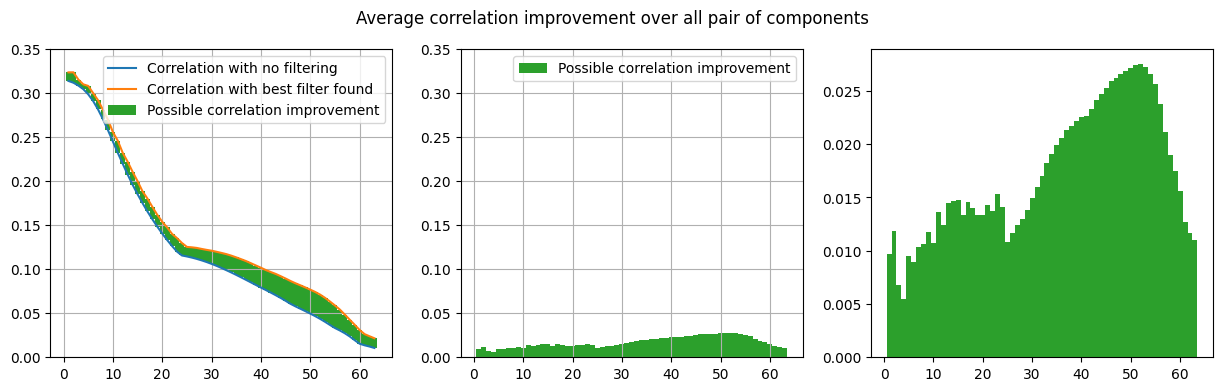

In [13]:
plot_avg_improvement()

This plot shows the average correlation obtained using the best filters from the Bayesian Optimisation for all the component pairs,
which means it is the average over the 3 * 3 * 63 = 567 filters.

We can visualize the sigma pairs obtained in a 2D plane, and apply clustering to reduce the amount of needed filters.

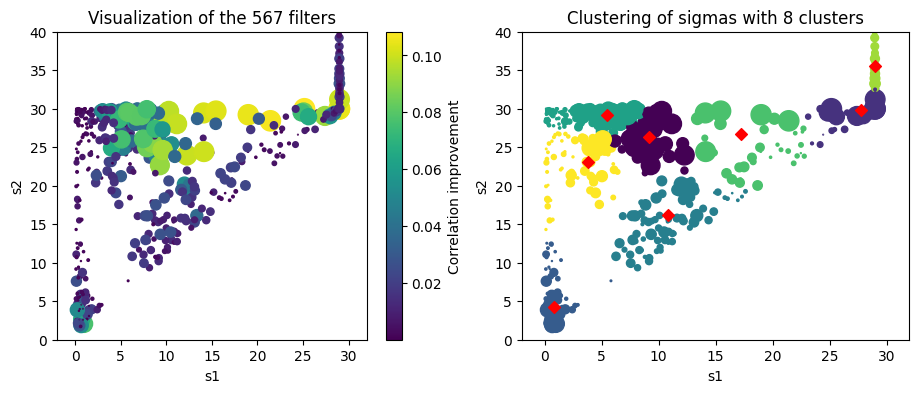

In [25]:
plot_clustering()

Here we arbitrarily choose 8 clusters, but we can compute the correlation with filters using the cluster center points.
If we do it for different amount of clusters, we can obtain an idea of the performance of each set of filters.

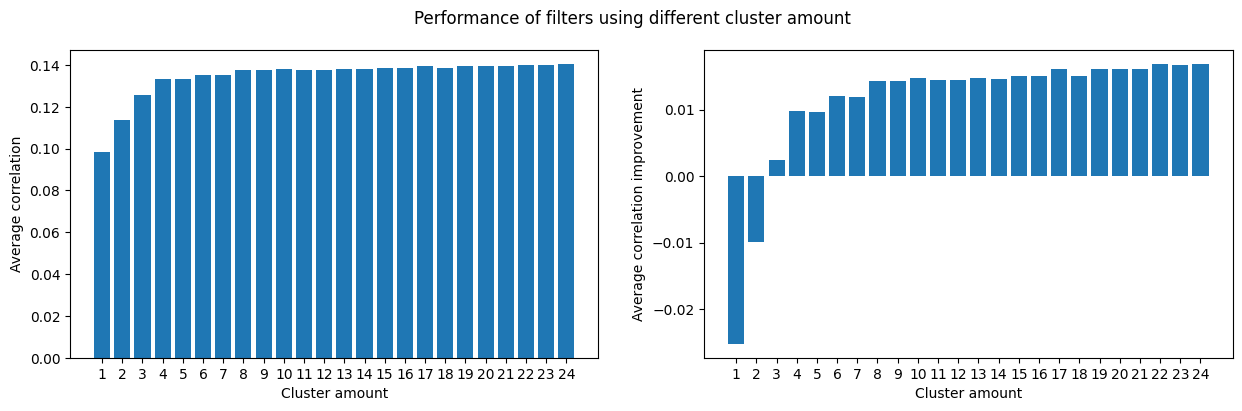

In [15]:
plot_kmeans_perf()

We want to maximise correlation improvement while minimising cluster amount. This compromise leads to choosing amongst 4, 6, 8 or 17 clusters.

Each filter used later will add one more layer to the input of the network, which result in more intensive computation.
Fortunately, at the scale of the whole network, the input layer has only a small influence, but input size should still be maintained as small as possible. 


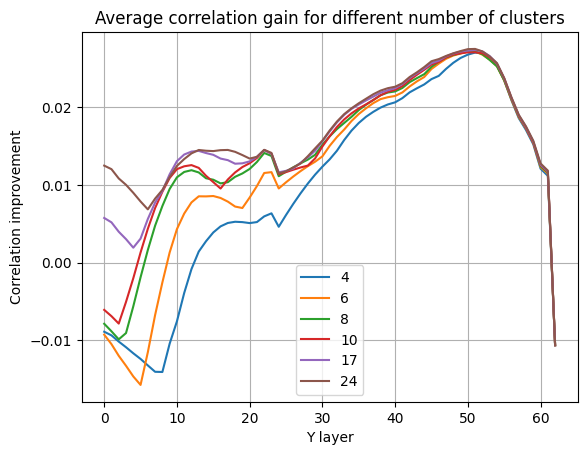

In [16]:
plot_kmeans_comp()

Since we focus on the 10+ Y layer, 8 clusters appear to be the best choice.

## Reducing the amount of combinaison considered

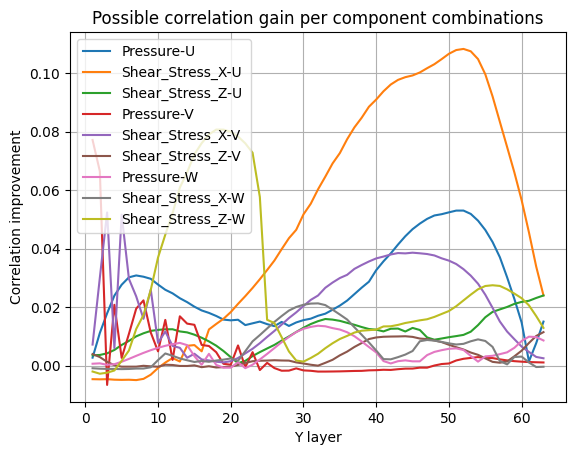

In [17]:
plot_corr_gains()


From the 9 pairs of input to output, we will only consider the 4 most relevant, which are:
- Shear Stress X to U (1, 0)
- Pressure to U (0, 0)
- Shear Stress X to V (1, 1)
- Shear Stress Z to W (2, 2)

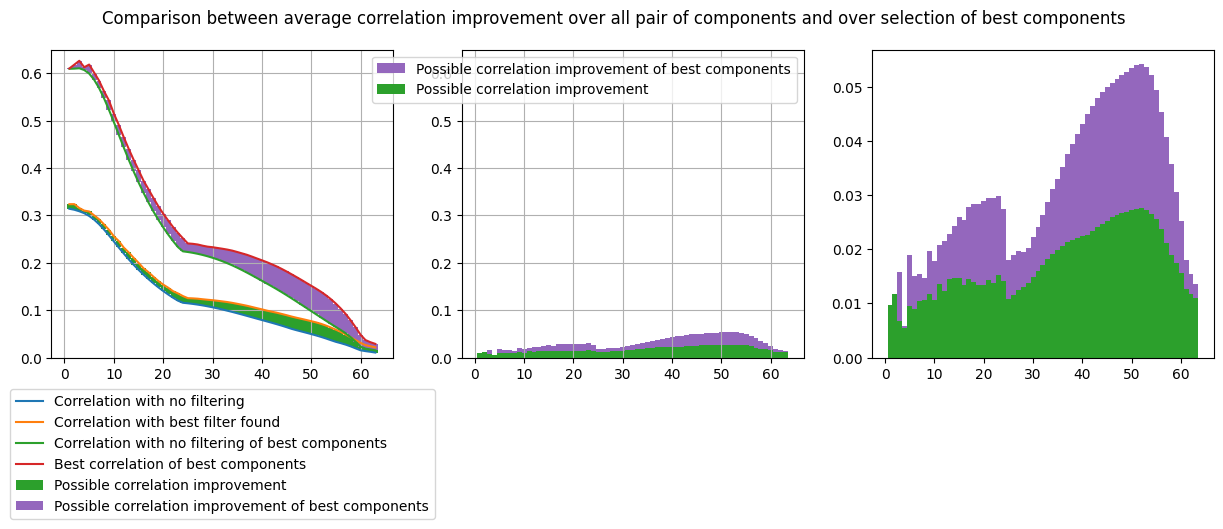

In [18]:
plot_diff_improvement()

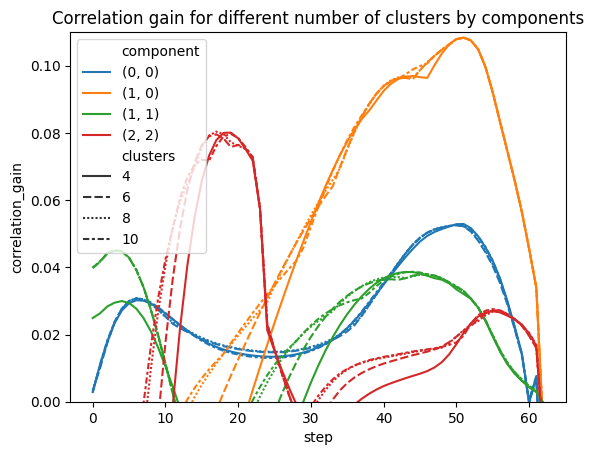

In [19]:
plot_gain_cluster_comp()

When considering only the best components, 8 clusters still appear to be the best choice, but the components are not equally well improved.
Pressure to U has similar improvement regardless of the amount of clusters, meaning that 4 clusters are enough, but the other component pairs need more.

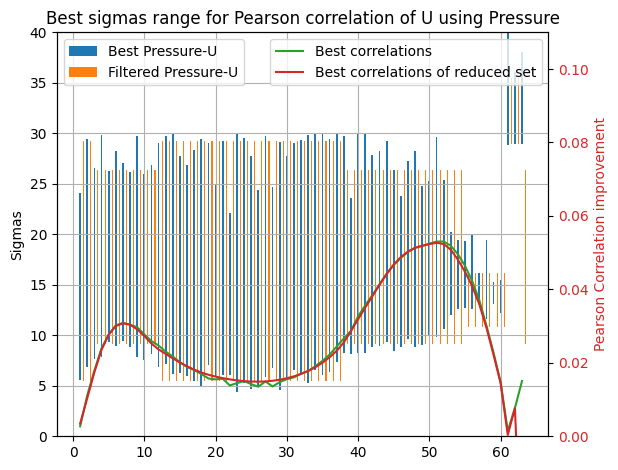

In [20]:
plot_used_sigmas(0, 0)

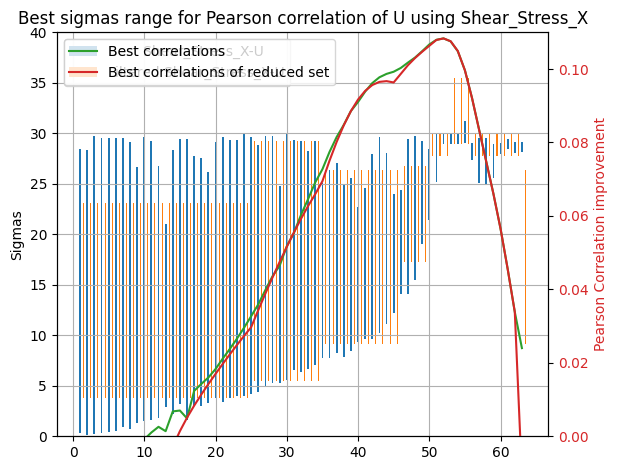

In [21]:
plot_used_sigmas(1, 0)

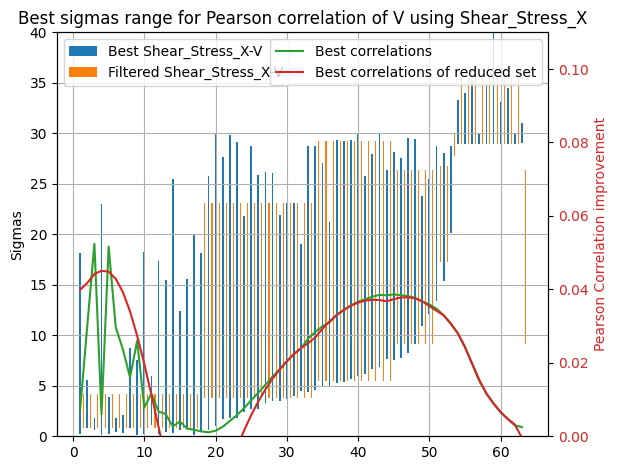

In [22]:
plot_used_sigmas(1, 1)

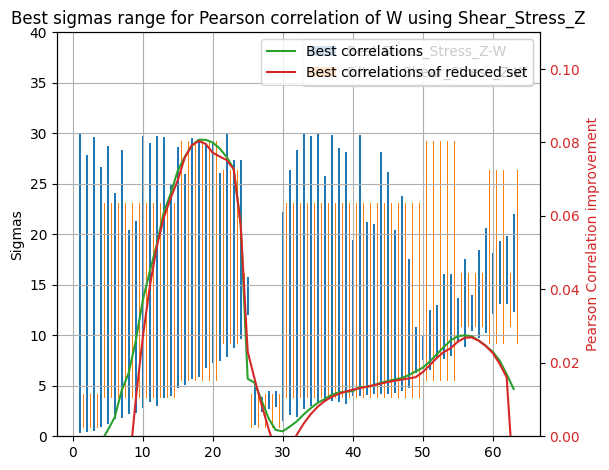

In [23]:
plot_used_sigmas(2, 2)

- Show result of training with scale filtering
- Check if diffusion gets better results with scale filtering
- Check if diffusion can predict nicely the close channel range